# Sistema de 3 ecuaciones diferenciales ordinarias de primer orden

**Alumno: Franco David Barrionuevo** <br>
**Docentes: Carolina Tauro, César Germán Maglione**

**Año:** 2026

In [46]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits import mplot3d
import pandas as pd
import math

### **a)** Realizá un programa para resolver un sistema de 3 ecuaciones diferenciales ordinarias de primer orden utilizando el método de integración de Euler

In [3]:
# Define Euler Solver in Python
def euler_solver_3d(f1, f2, f3, t0, tf, x10, x20, x30, h):
    '''
    f1: EDO f(t); f2: EDO g(t); f3: EDO h(t)
    t0: Tiempo inicial; tf: Tiempo final
    x10, x20 y x30: Condiciones iniciales dimensiones 1, 2 y 3
    h: Timestep 
    '''

    # Define steps
    steps = int((tf-t0)/h)

    # Initialize variables
    x1 = x10
    x2 = x20
    x3 = x30
    t = t0

    t_list = [t]
    x1_list = [x1]
    x2_list = [x2]
    x3_list = [x3]


    # For loop
    for i in range(steps):

        x1_old = x1
        x2_old = x2
        x3_old = x3

        x1 = x1_old + h*f1(t, x1_old, x2_old, x3_old)
        x2 = x2_old + h*f2(t, x1_old, x2_old, x3_old)
        x3 = x3_old + h*f3(t, x1_old, x2_old, x3_old)
        t = t + h

        t_list.append(t)
        x1_list.append(x1)
        x2_list.append(x2)
        x3_list.append(x3)

    return np.array(t_list), np.array(x1_list), np.array(x2_list), np.array(x3_list)

### **b)** Utilizá este programa para integrar numéricamente las *ecuaciones de Lorenz*

$\dot{x} = \sigma(y-x)$ <br>
$\dot{y} = rx-y-xz$ <br>
$\dot{z} = xy-bz$

Donde $\sigma = 10$, $r=28$ y $b = 8/3$ son parámetros del problema



In [4]:
# Define parameters values
SIGMA = 10
RHO = 28
BETA = 8/3

# Define df/dt for numerical integration
def dxdt(t, x1,x2, x3):
    # x1: x, x2: y; x3: z
    return SIGMA*(x2-x1)

def dydt(t, x1, x2, x3):
    # x1: x, x2: y; x3: z
    return RHO*x1-x2-x1*x3

def dzdt(t, x1, x2, x3):
    # x1: x, x2: y; x3: z
    return x1*x2-BETA*x3

### c) Comenzando con la condición inicial x(0) = 0, y(0) = 1 y z(0) = 0

#### c1) Graficá la solución x(t), y(t) y z(t).
#### c2) Realizá gráficos de la trayectoria en los tres planos coordenados (x − z), (x − y) y (z − y).
#### c3) Graficá la trayectoria en el espacio de la fases tridimensional.

In [49]:
# Define initial conditions
X10 = 0
X20 = 1
X30 = 0

# Define Euler parameters values
T0 = 0
TF = 100
H = 0.01

# Solve equations using the Euler implementation
t, x1, x2, x3 = euler_solver_3d(dxdt, dydt, dzdt, 
                   T0, TF, 
                   X10, X20, X30, 
                   H)


**Gráficos de x(t), y(t) y z(t)**

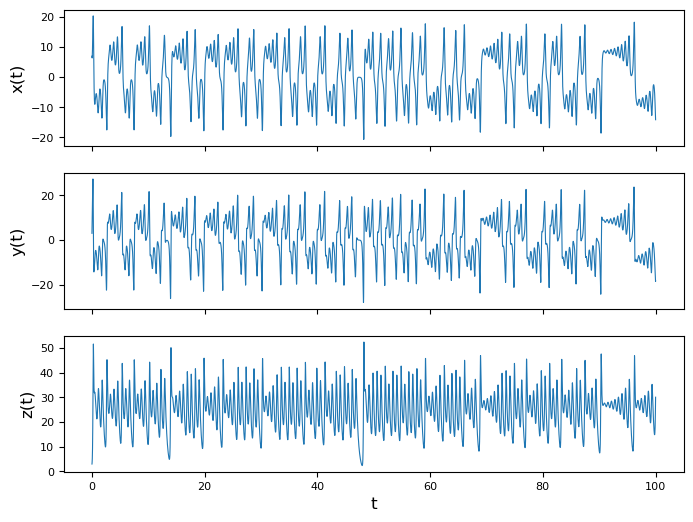

In [65]:
# Plot euler solver results (X1, X2 & X3 vs time phases map)
fig, ax = plt.subplots(3, 1, figsize=(8, 6), sharex = True)

ax[0].plot(t, x1, lw = 0.8)
ax[1].plot(t, x2, lw = 0.8)
ax[2].plot(t, x3, lw = 0.8)

for i, l in enumerate(['x', 'y', 'z']):
    ax[i].set_ylabel(f'{l}(t)', fontsize = 12)
    ax[i].tick_params(axis='y', labelsize=8) 

ax[2].set_xlabel(f't', fontsize = 12)
ax[2].tick_params(axis='x', labelsize=8)

**Respuesta**

--

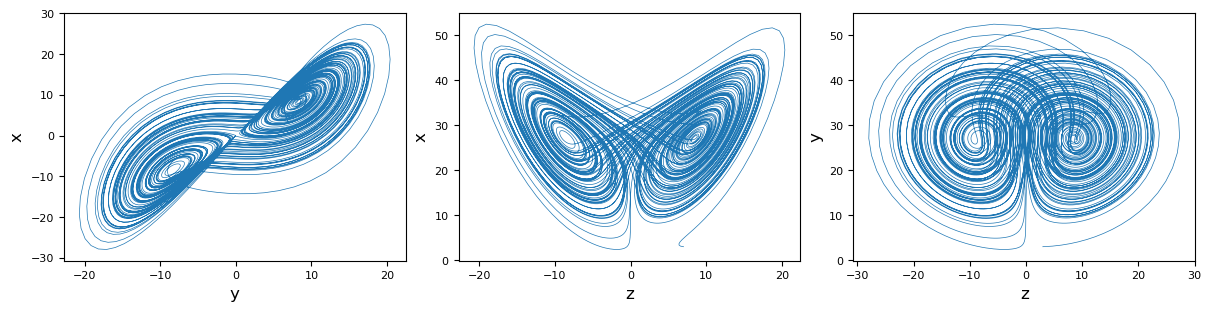

In [64]:
fig, ax = plt.subplots(1, 3, figsize=(12, 3), layout='constrained')

ax[0].plot(x1, x2, lw = 0.5)
ax[1].plot(x1, x3, lw = 0.5)
ax[2].plot(x2, x3, lw = 0.5)

list_axis = [('x', 'y'), ('x', 'z'), ('y', 'z')]

for i, xs in enumerate(list_axis):
    ax[i].set_ylabel(xs[0], fontsize = 12)
    ax[i].tick_params(axis='y', labelsize=8) 

    ax[i].set_xlabel(xs[1], fontsize = 12)
    ax[i].tick_params(axis='x', labelsize=8)

**Respuesta**

--

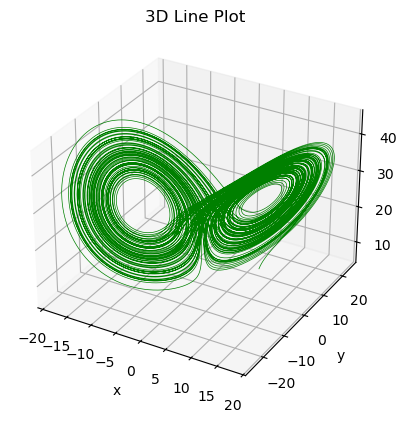

In [97]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')

ax.plot3D(x1, x2, x3, 'green', lw = 0.5)
ax.set_title('3D Line Plot')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z', labelpad=10)
plt.show()

### d) Realizá el diagrama de fases del problema usando al menos 3 condiciones iniciales diferentes. Para cada una de estas trayectorias realizá los gráficos de x(t), y(t) y z(t). Graficá las soluciones con colores diferentes.


In [56]:
import random

# Define random initial conditions
X10 = random.randint(0, 10)
X20 = random.randint(0, 10)
X30 = random.randint(0, 10)

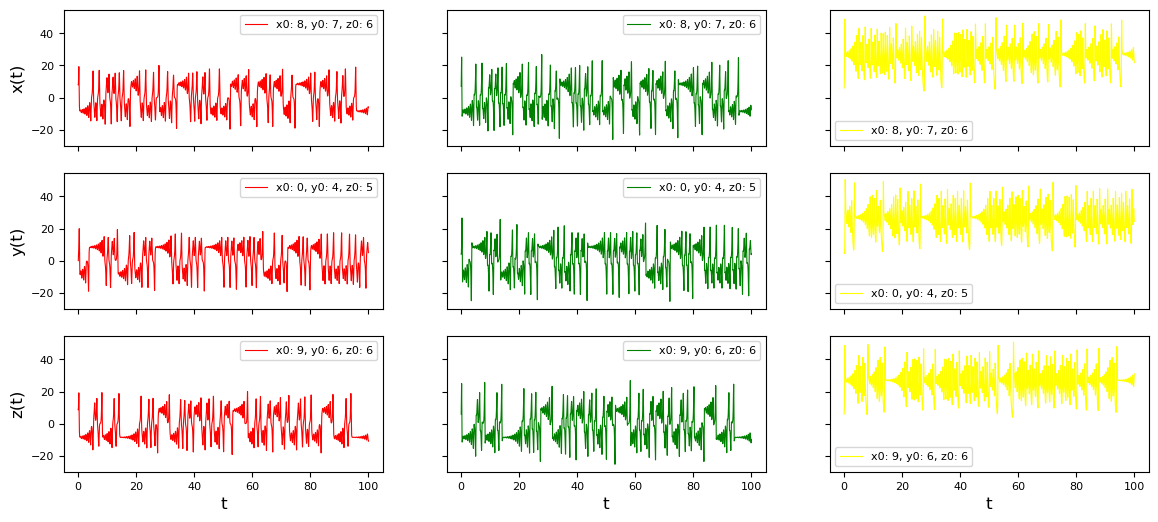

In [80]:
# Plot euler solver results (X1, X2 & X3 vs time phases map)
fig, ax = plt.subplots(3, 3, figsize=(14, 6), sharex = True, sharey = True)

# Define columns index
j = 0

# Define a list of colors
list_color = ['red', 'green', 'yellow']

# 
for i in range(3):

    # Define initial conditions
    X10, X20, X30 = random.randint(0, 10), random.randint(0, 10), random.randint(0, 10)

    t, x1, x2, x3 = euler_solver_3d(dxdt, dydt, dzdt, 
                    T0, TF, 
                    X10, X20, X30, 
                    H)

    ax[i, j].plot(t, x1, lw = 0.8, color = list_color[0], label = f'x0: {X10}, y0: {X20}, z0: {X30}')
    ax[i, j+1].plot(t, x2, lw = 0.8, color = list_color[1], label = f'x0: {X10}, y0: {X20}, z0: {X30}')
    ax[i, j+2].plot(t, x3, lw = 0.8, color = list_color[2], label = f'x0: {X10}, y0: {X20}, z0: {X30}')

    ax[i, j].legend(fontsize=8)
    ax[i, j+1].legend(fontsize=8)
    ax[i, j+2].legend(fontsize=8)


    for i, l in enumerate(['x', 'y', 'z']):
        ax[i, 0].set_ylabel(f'{l}(t)', fontsize = 12)
        ax[i, 0].tick_params(axis='y', labelsize=8) 

        ax[2, i].set_xlabel(f't', fontsize = 12)
        ax[2, i].tick_params(axis='x', labelsize=8)    

### d) Teniendo en cuenta los resultados de los puntos anteriores... ¿qué le ocurre al sistema cuando se inicializa con condiciones levemente diferentes?

**Respuesta**

--

### e)  Elegí una condición inicial y analizá cómo influye la elección del paso de integración.

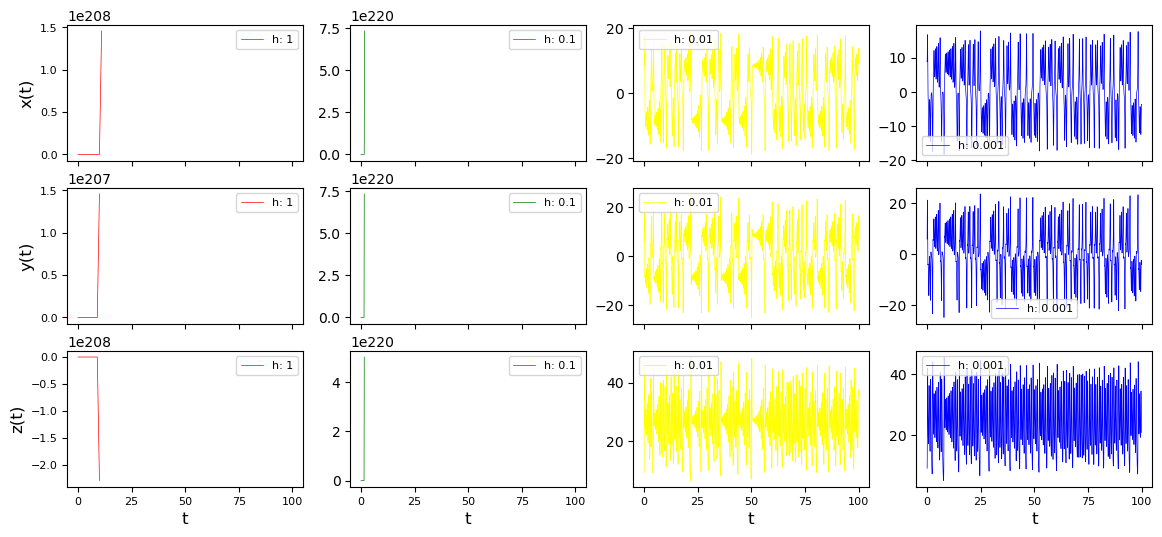

In [90]:
# Define initial conditions
X10 = 9
X20 = 6
X30 = 9

# Define a list of h
list_h = [1, 0.1, 0.01, 0.001]

# Plot euler solver results (X1, X2 & X3 vs time phases map)
fig, ax = plt.subplots(3, 4, figsize=(14, 6), sharex = True)

# Define columns index
j = 0

# Define a list of colors
list_color = ['red', 'green', 'yellow', 'blue']

# 
for i, H in enumerate(list_h):

    t, x1, x2, x3 = euler_solver_3d(dxdt, dydt, dzdt, 
                    T0, TF, 
                    X10, X20, X30, 
                    H)

    ax[j, i].plot(t, x1, lw = 0.5, color = list_color[i], label = f'h: {H}')
    ax[j+1, i].plot(t, x2, lw = 0.5, color = list_color[i], label = f'h: {H}')
    ax[j+2, i].plot(t, x3, lw = 0.5, color = list_color[i], label = f'h: {H}')

    ax[j, i].legend(fontsize=8)
    ax[j+1, i].legend(fontsize=8)
    ax[j+2, i].legend(fontsize=8)


    for i, l in enumerate(['x', 'y', 'z']):
        ax[i, 0].set_ylabel(f'{l}(t)', fontsize = 12)
        ax[i, 0].tick_params(axis='y', labelsize=8) 

    for i in range(4):
        ax[2, i].set_xlabel(f't', fontsize = 12)
        ax[2, i].tick_params(axis='x', labelsize=8) 

**Respuesta**

--

### e) Este sistema tiene un atractor extraño o caótico, muchas veces conocido como mariposa de Lorenz, de donde se popularizó el llamado efecto mariposa... te animás a especular el porqu´e de este nombre?

**Respuesta**

--